# Drowsiness Detection - Colab Ready

Pipeline: Camera/Video → Face → Eyes → CNN (open/closed) → Drowsiness Score → Alert

**Run all cells in order.**

## 1. Imports

In [ ]:
import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prasadvpatil/mrl-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'mrl-dataset' dataset.
Path to dataset files: /kaggle/input/mrl-dataset


In [ ]:
from pathlib import Path
Base_DIR = Path(path)
print(Base_DIR)

/kaggle/input/mrl-dataset


In [ ]:
!ls {Base_DIR}

train


In [ ]:
DATA_DIR = Base_DIR / "train"
print(DATA_DIR)

/kaggle/input/mrl-dataset/train


In [ ]:
! ls {DATA_DIR}

Closed_Eyes  Open_Eyes


## Load the data

In [ ]:
import tensorflow as tf
from pathlib import Path

IMG_SIZE = (64, 64)
BATCH_SIZE = 32
SEED = 42

full_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    label_mode="binary"
)

class_names = full_ds.class_names
print("Classes:", class_names)


Found 4000 files belonging to 2 classes.
Classes: ['Closed_Eyes', 'Open_Eyes']


/tmp/ipython-input-4225539744.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label_name = class_names[int(labels[i].numpy())]


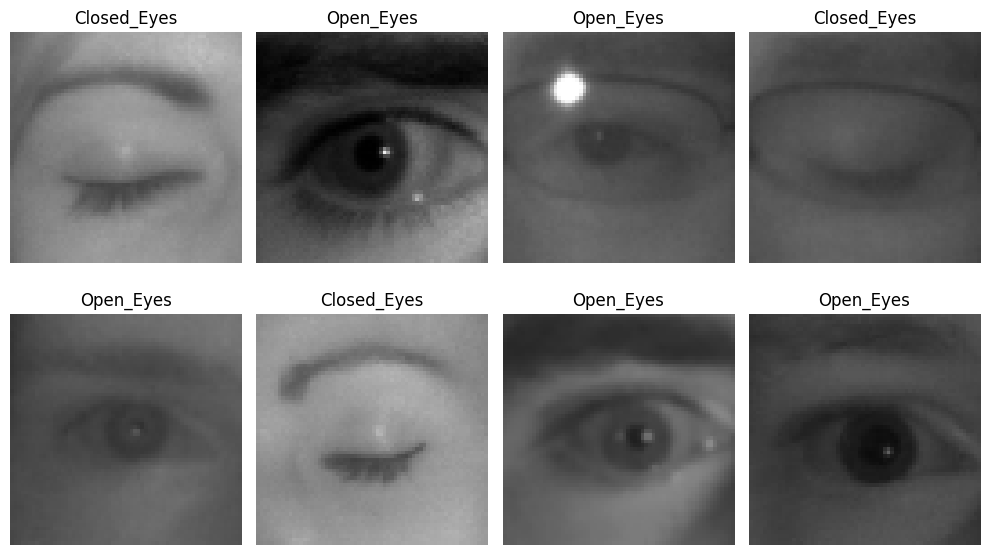

In [ ]:
# Plot the images
import matplotlib.pyplot as plt

images, labels = next(iter(full_ds))

plt.figure(figsize=(10, 6))
for i in range(8):
    ax = plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    label_name = class_names[int(labels[i].numpy())]
    plt.title(label_name)
    plt.axis("off")
plt.tight_layout()
plt.show()


### Use Autogenralization to generalize

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.03),
    tf.keras.layers.RandomZoom(0.05),
    tf.keras.layers.RandomBrightness(0.05),
])


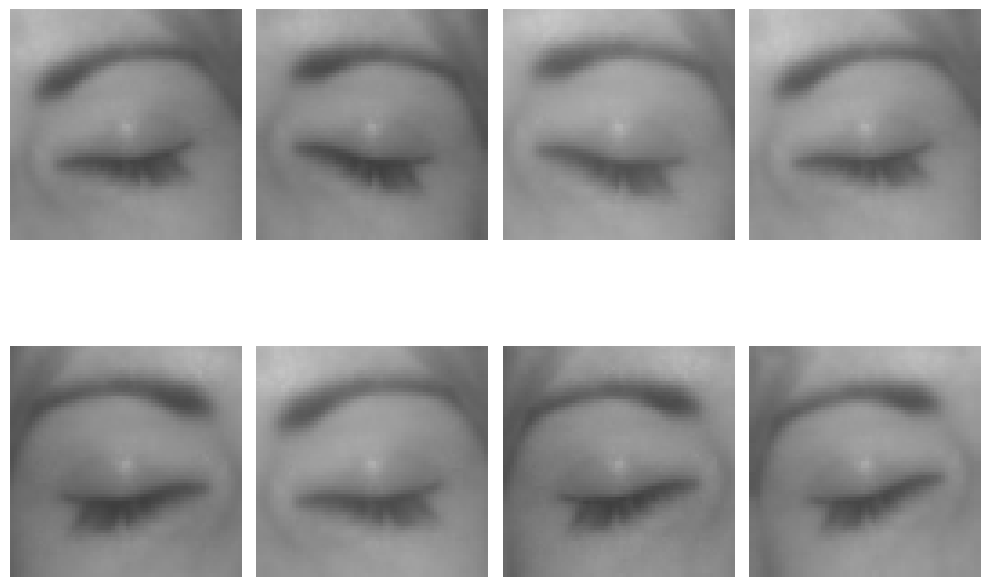

In [ ]:
img = images[0:1]  # one image, keep batch dim

plt.figure(figsize=(10, 8))
for i in range(8):
    ax = plt.subplot(2, 4, i + 1)
    aug_img = data_aug(img, training=True)[0]
    plt.imshow(aug_img.numpy().astype("uint8"))
    plt.axis("off")
plt.tight_layout()
plt.show()


# split data into train _val _test

In [ ]:
ds_len = len(full_ds)
train_len = int(0.70 * ds_len)
val_len   = int(0.15 * ds_len)

train_ds = full_ds.take(train_len)
val_ds   = full_ds.skip(train_len).take(val_len)
test_ds  = full_ds.skip(train_len + val_len)

print("Batches -> full:", ds_len, "train:", len(train_ds), "val:", len(val_ds), "test:", len(test_ds))

Batches -> full: 125 train: 87 val: 18 test: 20


In [ ]:
def prep_train(x, y):
    x = tf.cast(x, tf.float32) / 255.0
    x = data_aug(x, training=True)
    return x, y

def prep_eval(x, y):
    x = tf.cast(x, tf.float32) / 255.0
    return x, y

train_ds = train_ds.map(prep_train, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
val_ds   = val_ds.map(prep_eval,  num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
test_ds  = test_ds.map(prep_eval,  num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)


## Model architecture ( Train from sratch)

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),
    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from pathlib import Path

MODEL_PATH = Path("/content/eye_model.keras")


callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(MODEL_PATH),
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

print("Saved best model to:", MODEL_PATH)


Epoch 1/10
84/87 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4809 - loss: 0.7402
Epoch 1: val_loss improved from inf to 0.68812, saving model to /content/eye_model.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.4814 - loss: 0.7390 - val_accuracy: 0.5243 - val_loss: 0.6881
Epoch 2/10
84/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5074 - loss: 0.7001
Epoch 2: val_loss improved from 0.68812 to 0.68267, saving model to /content/eye_model.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5078 - loss: 0.6999 - val_accuracy: 0.8611 - val_loss: 0.6827
Epoch 3/10
83/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5014 - loss: 0.7002
Epoch 3: val_loss improved from 0.68267 to 0.67300, saving model to /content/eye_model.keras
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5021 - loss: 0.7000 - val_accuracy: 0.5017 - val_loss: 0.6730
Epoch 4/10
82/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5254 - loss: 0.6945
Epoch 4: val_loss improved from 0.67300 to 

In [ ]:
# Evaluate the model on test datasets
test_loss, test_acc = model.evaluate(test_ds)
print("Test accuracy:", test_acc)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9487 - loss: 0.2133
Test accuracy: 0.949999988079071


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


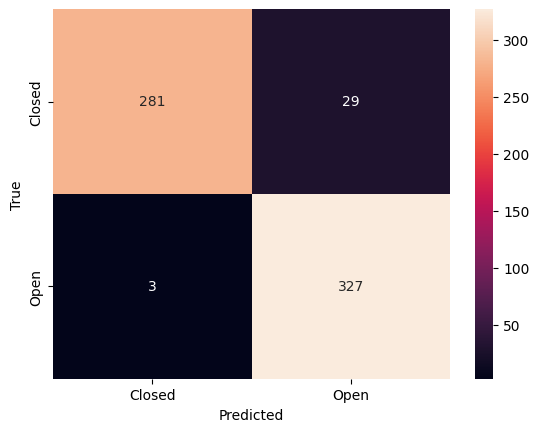

              precision    recall  f1-score   support

         0.0       0.99      0.91      0.95       310
         1.0       0.92      0.99      0.95       330

    accuracy                           0.95       640
   macro avg       0.95      0.95      0.95       640
weighted avg       0.95      0.95      0.95       640



In [ ]:
# confusion matrix
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy().flatten())
    y_pred.extend(preds.flatten())

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Closed", "Open"],
            yticklabels=["Closed", "Open"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

print(classification_report(y_true, y_pred))


In [ ]:
import cv2
print(cv2.__version__)

4.13.0


## Load the model and do the drowsiness in real time

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from tensorflow.keras.models import load_model
model = load_model('/content/drive/MyDrive/eye_model.keras')


In [ ]:
model.input_shape

(None, 64, 64, 3)

In [ ]:
from IPython.display import Javascript, display
from google.colab.output import eval_js


In [ ]:
import time, base64, numpy as np, cv2
import matplotlib.pyplot as plt
from IPython.display import Javascript, display
from google.colab.output import eval_js

IMG_SIZE = 64  # change if needed

# 1️⃣ Inject + Start webcam in THIS output
display(Javascript(r"""
(()=> {
  const W = window.__webcam__ = window.__webcam__ || {};

  W.stop = () => {
    try { W.s && W.s.getTracks().forEach(t => t.stop()); } catch(e){}
    W.s=null;
    if(W.v){W.v.remove();W.v=null}
    W.c=null;W.x=null;
    return "stopped";
  };

  W.start = async () => {
    if(W.s && W.v) return "already started";

    W.v = document.createElement("video");
    W.v.autoplay=true;
    W.v.playsInline=true;
    W.v.style.width="480px";

    W.c=document.createElement("canvas");
    W.c.width=480; W.c.height=360;
    W.x=W.c.getContext("2d");

    W.s = await navigator.mediaDevices.getUserMedia({video:true});
    W.v.srcObject=W.s;
    document.body.appendChild(W.v);

    await new Promise(r=>W.v.onloadedmetadata=r);
    await W.v.play();

    W.ready=true;
    return "started";
  };

  W.cap = () => {
    if(!W.ready || !W.v) return "";
    W.x.drawImage(W.v,0,0,W.c.width,W.c.height);
    return W.c.toDataURL("image/jpeg",0.8);
  };

  window.startWebcam = W.start;
  window.captureFrame = W.cap;
  window.stopWebcam = W.stop;
})();
"""))

print("start:", eval_js("startWebcam()"))

def preprocess(frame):
    img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32) / 255.0
    return np.expand_dims(img, axis=0)



#
import time, base64, numpy as np, cv2
from google.colab.output import eval_js

# --- detectors (eye crop) ---
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
eye_cascade  = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")

IMG_SIZE = 64

def preprocess_eyes(frame_bgr):
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.2, minNeighbors=5)

    crop = frame_bgr  # fallback: full frame
    if len(faces) > 0:
        x, y, fw, fh = max(faces, key=lambda b: b[2]*b[3])
        face_gray = gray[y:y+fh, x:x+fw]
        face_bgr  = frame_bgr[y:y+fh, x:x+fw]

        eyes = eye_cascade.detectMultiScale(face_gray, scaleFactor=1.15, minNeighbors=5)
        if len(eyes) > 0:
            eyes = sorted(eyes, key=lambda e: e[1])[:2]
            x1 = min(e[0] for e in eyes)
            y1 = min(e[1] for e in eyes)
            x2 = max(e[0] + e[2] for e in eyes)
            y2 = max(e[1] + e[3] for e in eyes)

            pad = int(0.25 * (y2 - y1 + 1))
            y1 = max(0, y1 - pad)
            y2 = min(face_bgr.shape[0], y2 + pad)
            crop = face_bgr[y1:y2, x1:x2]
        else:
            crop = face_bgr

    crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    crop = cv2.resize(crop, (IMG_SIZE, IMG_SIZE))
    crop = crop.astype(np.float32) / 255.0
    return np.expand_dims(crop, axis=0)


# --------------------------
# ALARM SETTINGS
# --------------------------
# Your mapping seems: high score => ALERT, low score => DROWSY
DROWSY_THRESHOLD = 0.50      # score < threshold -> drowsy frame
NEEDED_CONSEC = 6            # frames in a row required to confirm drowsy
ALARM_COOLDOWN = 5.0         # seconds between alarms (prevents spam)

drowsy_count = 0
last_alarm_time = 0.0

def trigger_alarm(score, streak):
    """Simple alarm: beep + console warning. (Works in Colab.)"""
    global last_alarm_time
    now = time.time()
    if now - last_alarm_time < ALARM_COOLDOWN:
        return  # still in cooldown

    last_alarm_time = now
    print("\n🚨🚨🚨 ALARM! DROWSINESS DETECTED 🚨🚨🚨")
    print(f"score={score:.2f} | streak={streak}/{NEEDED_CONSEC}\n")

    # Beep in notebook output (may not work on every device, but usually does)
    print('\a')  # terminal bell
    try:
        from IPython.display import Audio, display
        # quick generated tone using numpy (no extra files)
        import numpy as np
        sr = 22050
        t = np.linspace(0, 0.35, int(sr*0.35), False)
        tone = 0.5*np.sin(2*np.pi*880*t)
        display(Audio(tone, rate=sr, autoplay=True))
    except:
        pass


# --------------------------
# REAL-TIME LOOP
# Stop with ⏹ or Runtime -> Interrupt execution
# --------------------------
for i in range(1000):
    data_url = eval_js("captureFrame()")
    if not data_url:
        print("No frame (empty)")
        break

    _, encoded = data_url.split(",", 1)
    frame = cv2.imdecode(
        np.frombuffer(base64.b64decode(encoded), np.uint8),
        cv2.IMREAD_COLOR
    )
    if frame is None:
        print("Decode failed")
        continue

    x = preprocess_eyes(frame)
    pred = model.predict(x, verbose=0)
    score = float(pred[0][0])

    # drowsy logic
    if score < DROWSY_THRESHOLD:
        drowsy_count += 1
    else:
        drowsy_count = 0

    # status
    if drowsy_count >= NEEDED_CONSEC:
        status = "DROWSY ✅"
        trigger_alarm(score, drowsy_count)
    else:
        status = "ALERT"

    print(f"{i+1}: {status} | score={score:.2f} | streak={drowsy_count}")
    time.sleep(0.25)

eval_js("stopWebcam()")





<IPython.core.display.Javascript object>

start: started
1: ALERT | score=0.20 | streak=1
2: ALERT | score=0.36 | streak=2
3: ALERT | score=0.41 | streak=3
4: ALERT | score=0.39 | streak=4
5: ALERT | score=0.61 | streak=0
6: ALERT | score=0.54 | streak=0
7: ALERT | score=0.56 | streak=0
8: ALERT | score=0.54 | streak=0
9: ALERT | score=0.55 | streak=0
10: ALERT | score=0.52 | streak=0
11: ALERT | score=0.51 | streak=0
12: ALERT | score=0.50 | streak=0
13: ALERT | score=0.41 | streak=1
14: ALERT | score=0.42 | streak=2
15: ALERT | score=0.48 | streak=3
16: ALERT | score=0.42 | streak=4
17: ALERT | score=0.42 | streak=5

🚨🚨🚨 ALARM! DROWSINESS DETECTED 🚨🚨🚨
score=0.40 | streak=6/6




18: DROWSY ✅ | score=0.40 | streak=6
19: DROWSY ✅ | score=0.38 | streak=7
20: DROWSY ✅ | score=0.45 | streak=8
21: DROWSY ✅ | score=0.44 | streak=9
22: DROWSY ✅ | score=0.40 | streak=10
23: DROWSY ✅ | score=0.39 | streak=11
24: DROWSY ✅ | score=0.47 | streak=12
25: DROWSY ✅ | score=0.47 | streak=13

🚨🚨🚨 ALARM! DROWSINESS DETECTED 🚨🚨🚨
score=0.47 | streak=14/6




26: DROWSY ✅ | score=0.47 | streak=14
27: DROWSY ✅ | score=0.44 | streak=15


KeyboardInterrupt: 